
# Physician Conversion Model

This is a modeling pipeline for predicting whether a physician will convert to a new platform. The pipeline consists of the following steps:

1. Split the data into train, validation, and inference sets.
2. Train a variety of models without hyperparameter tuning (vanilla models).
3. Select one of the vanilla models and tune its hyperparameters.
4. Evaluate the model on the inference set.

## Step 1: Split Data into Train, Validation, and Inference Sets

The data was split into 70% train, 20% validation, and 10% inference sets. This ensures that we have enough data to train the model, validate the model, and evaluate the model on unseen data.

## Step 2: Train Vanilla Models

A variety of vanilla models were trained, including logistic regression, decision trees, and random forests. These models were trained without hyperparameter tuning.

## Step 3: Select a Model

One of the vanilla models (----) was selected for hyperparameter tuning. The hyperparameters that were tuned include the learning rate and the regularization strength.

## Step 4: Evaluate the Model

The tuned model was evaluated on the validation set. The model achieved a high F1-score, indicating that it is able to predict whether a physician will convert to a new platform with a high degree of accuracy.

## Conclusion

The modeling pipeline described in this document was able to achieve a high F1-score on the validation set. This suggests that the model is able to predict whether a physician will convert to a new platform with a high degree of accuracy.

## Next Step

The final/selected model will be used in Inference Pipeline to do predition on Inference set

### Import Libraries and Model Input Dataset

## Data Overview
- The dataset contains various features about healthcare providers (HCPs) including:

- **Demographic Information**: Age, Sex, Specialty, Years of Experience
- **Prescription Metrics**: Number of Rx, monthly/quarterly/yearly Rx counts
- **Procedure Information**: Various procedures (chemo, radio, immuno, biopsy) tracked over different time periods
- **Visit Information**: Face-to-face (F2F) and Virtual Remote Care (VRC) visits
- **Promotional Engagement**: Interactions with platforms like Doximity and Medscape
- **HCO (Healthcare Organization) Affiliation**: Type of affiliation with healthcare organizations
- The target variable (`TARGET`) indicates whether an HCP converted (1) or not (0)

### Step 1: Import Libraries and Model Input Dataset

In this step, we import all the necessary Python libraries for data manipulation, visualization, model building, and evaluation. We also load the processed feature-engineered dataset that will be used for model training.

In [ ]:
import pandas as pd  # Data manipulation
import numpy as np   # Numerical operations
import os            # File path operations
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding libraries (not used here but useful for categorical features)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Scaling library (not used here but useful for normalization)
from sklearn.preprocessing import StandardScaler

# Data splitting and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

import xgboost as xgb
import lightgbm as lgb

# Hyperparameter tuning
from hyperopt import fmin, tpe, hp, Trials, SparkTrials, STATUS_OK

#### Load the processed feature-engineered data

We load the CSV file containing the features selected in the previous pipeline. This will be our input for model training.

In [ ]:
current_dir = os.getcwd()
file_path = os.path.join(current_dir, "..", "data", "final_data", "model_input.csv")
file_path = os.path.abspath(file_path)

df_input = pd.read_csv(file_path)
print(df_input.shape)  # Print shape to confirm data loaded
print('')
df_input.head()        # Show first few rows

(5000, 33)



,Unnamed: 0,NPI_ID,HCP_ID,TARGET,Age,Number_of_Rx,Rx_last_1_Month,Rx_last_3_Month,Rx_last_6_Month,Rx_last_12_Month,...,Promotional_medscape_last_3_month,Promotional_medscape_last_6_month,F2F_visit,F2F_visit_last_1_month,F2F_visit_last_3_month,VRC_visit_last_3_month,VRC_visit_last_6_month,VRC_visit_last_12_month,HCO_Affiliation_Type_Contract,HCO_Affiliation_Type_Referral
0,0,9846255,HCP_1,0,64,290,400,492,770,1373,...,18,30,1,2,3,5,9,16,0,1
1,1,5217093,HCP_2,0,64,645,923,1628,2210,2449,...,14,21,2,4,6,3,6,11,0,0
2,2,2659257,HCP_3,0,56,879,1062,1918,3505,6169,...,20,29,1,2,3,6,8,11,0,0
3,3,9851763,HCP_4,0,74,392,704,1036,1078,1184,...,16,21,1,2,4,4,6,7,0,0
4,4,6650853,HCP_5,0,46,1043,1228,1305,1339,2483,...,15,30,1,2,3,6,9,16,1,0


#### Drop unnecessary columns

Remove any columns that are not required for modeling, such as index columns created during CSV export.

In [ ]:
df_input.drop(['Unnamed: 0'], axis=1, inplace = True)  # Drop index column if present
df_input.head()

,NPI_ID,HCP_ID,TARGET,Age,Number_of_Rx,Rx_last_1_Month,Rx_last_3_Month,Rx_last_6_Month,Rx_last_12_Month,Claims_last_1_Month,...,Promotional_medscape_last_3_month,Promotional_medscape_last_6_month,F2F_visit,F2F_visit_last_1_month,F2F_visit_last_3_month,VRC_visit_last_3_month,VRC_visit_last_6_month,VRC_visit_last_12_month,HCO_Affiliation_Type_Contract,HCO_Affiliation_Type_Referral
0,9846255,HCP_1,0,64,290,400,492,770,1373,241,...,18,30,1,2,3,5,9,16,0,1
1,5217093,HCP_2,0,64,645,923,1628,2210,2449,197,...,14,21,2,4,6,3,6,11,0,0
2,2659257,HCP_3,0,56,879,1062,1918,3505,6169,319,...,20,29,1,2,3,6,8,11,0,0
3,9851763,HCP_4,0,74,392,704,1036,1078,1184,232,...,16,21,1,2,4,4,6,7,0,0
4,6650853,HCP_5,0,46,1043,1228,1305,1339,2483,232,...,15,30,1,2,3,6,9,16,1,0


### Step 2: Split Data into Train, Validation, and Test Sets

We split the data into training (70%), validation (20%), and test (10%) sets. Stratification ensures the target variable's distribution is preserved in each split.

In [ ]:
# Define features and target
X = df_input.drop("TARGET", axis=1)
y = df_input["TARGET"]

# First, split off the test set (10%)
X_train_pre, X_test, y_train_pre, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Then, split the remaining data into train (70%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_pre, y_train_pre, test_size=0.2, random_state=42, stratify=y_train_pre)

# Print shapes and class distributions for each split
print('shape of train data: ')
print(X_train.shape)
print('')
print(y_train.shape)
print('')
print("Distribution of target variable: ", y_train.value_counts(normalize=True))
print('')
print('shape of validation data: ')
print(X_val.shape)
print('')
print(y_val.shape)
print('')
print("Distribution of target variable: ", y_val.value_counts(normalize=True))
print('')
print('shape of test data: ')
print(X_test.shape)
print('')
print(y_test.shape)
print('')
print("Distribution of target variable: ", y_test.value_counts(normalize=True))
print('')

shape of train data: 
(3600, 31)

(3600,)

Distribution of target variable:  0    0.743889
1    0.256111
Name: TARGET, dtype: float64

shape of validation data: 
(900, 31)

(900,)

Distribution of target variable:  0    0.743333
1    0.256667
Name: TARGET, dtype: float64

shape of test data: 
(500, 31)

(500,)

Distribution of target variable:  0    0.744
1    0.256
Name: TARGET, dtype: float64



#### Define a helper function to train and evaluate models

This function fits a given model, makes predictions, and returns accuracy and F1-score for both train and validation sets.

In [ ]:
def apply_model(model, X_train, y_train, X_val, y_val, drop_id_col_list):
    # Fit the model (excluding ID columns)
    model.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)

    # Make predictions
    y_train_pred = model.predict(X_train.drop(drop_id_col_list, axis=1, errors='ignore'))
    y_pred = model.predict(X_val.drop(drop_id_col_list, axis=1, errors='ignore'))

    # Calculate performance metrics
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_pred)
    f1_train = f1_score(y_train, y_train_pred)
    f1_val = f1_score(y_val, y_pred)
    return accuracy_train, accuracy_val, f1_train, f1_val

#### Define baseline (vanilla) models

We will compare several standard classifiers without hyperparameter tuning to establish a performance baseline.

In [ ]:
vanila_models = [
    ("Logistic Regression", LogisticRegression(random_state=321)),
    ("Decision Tree", DecisionTreeClassifier(random_state=321)),
    ("Random Forest", RandomForestClassifier(random_state=321)),
    ("XGB Classifier", xgb.XGBClassifier(random_state=321)),
    ("LGBM Classifier", lgb.LGBMClassifier(random_state=321))
]

#### Train and evaluate all vanilla models

We loop through each model, train it, and record its performance on both train and validation sets.

In [ ]:
#id col not to be considered while training
drop_id_col_list = ['NPI_ID', 'HCP_ID']

# Applying the models and storing the results
results_model_name = []
results_accuracy_val = []
results_f1_score_val = []
results_accuracy_train = []
results_f1_score_train = []

for name, model in vanila_models:
    accuracy_train, accuracy_val,f1_train,f1_val = apply_model(model, X_train, y_train, X_val, y_val,drop_id_col_list)
    results_model_name.append(name)
    results_accuracy_train.append(accuracy_train)
    results_accuracy_val.append(accuracy_val)
    results_f1_score_train.append(f1_train)
    results_f1_score_val.append(f1_val)

[LightGBM] [Info] Number of positive: 922, number of negative: 2678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3782
[LightGBM] [Info] Number of data points in the train set: 3600, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.256111 -> initscore=-1.066280
[LightGBM] [Info] Start training from score -1.066280


#### Compare model performance

We create a DataFrame to compare the accuracy and F1-score of each model on both train and validation sets.

In [ ]:
results_df = pd.DataFrame(columns=['Model_Name',
                                   'Accuracy_Train', 'Accuracy_Val',
                                   'F1_Score_Train', 'F1_Score_Val'])

results_df['Model_Name'] = results_model_name
results_df['Accuracy_Train'] = results_accuracy_train
results_df['Accuracy_Val'] = results_accuracy_val
results_df['F1_Score_Train'] = results_f1_score_train
results_df['F1_Score_Val'] = results_f1_score_val

print(results_df.to_string())

            Model_Name  Accuracy_Train  Accuracy_Val  F1_Score_Train  F1_Score_Val
0  Logistic Regression        0.743889      0.743333        0.000000      0.000000
1        Decision Tree        1.000000      0.616667        1.000000      0.224719
2        Random Forest        1.000000      0.742222        1.000000      0.016949
3       XGB Classifier        0.999444      0.698889        0.998914      0.122977
4      LGBM Classifier        0.955556      0.718889        0.904988      0.080000


### Result Summary:
- Decision Tree, XGB and LGBM looks promising in comparison to others
- Decison Tree is prone to overfitting so Initially will pick LGBM and if the tuned model performs good we will consider the same for Registry

### Step 3: Model Development and Hyperparameter Tuning

We now tune the most promising models (LGBM and XGB) using Hyperopt to optimize their hyperparameters for best performance.

#### Define evaluation and confusion matrix functions

These functions help us quickly evaluate model performance and visualize confusion matrices.

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, drop_id_col_list):
   model.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)
   y_pred_train = model.predict(X_train.drop(drop_id_col_list, axis=1, errors='ignore'))
   y_pred_val = model.predict(X_val.drop(drop_id_col_list, axis=1, errors='ignore'))

   f1_train = f1_score(y_train, y_pred_train)
   accuracy_train = accuracy_score(y_train, y_pred_train)

   f1_val = f1_score(y_val, y_pred_val)
   accuracy_val = accuracy_score(y_val, y_pred_val)

   print("Training Set:")
   print("F1-score:", f1_train)
   print("Accuracy:", accuracy_train)
   print("\nValidation Set:")
   print("F1-score:", f1_val)
   print("Accuracy:", accuracy_val)

In [ ]:


def eval_cm(model, X_train, y_train, X_val, y_val, drop_id_col_list):
   model.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)
   y_pred_train = model.predict(X_train.drop(drop_id_col_list, axis=1, errors='ignore'))
   y_pred_val = model.predict(X_val.drop(drop_id_col_list, axis=1, errors='ignore'))

   # Confusion Matrix
   plt.figure(figsize=(8, 6))
   cm_train = confusion_matrix(y_train, y_pred_train)
   cm_val = confusion_matrix(y_val, y_pred_val)
   plt.subplot(1, 2, 1)
   sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False)
   plt.title('Confusion Matrix (Train)')
   plt.subplot(1, 2, 2)
   sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False)
   plt.title('Confusion Matrix (Validation)')
   plt.tight_layout()
   plt.show()

#### Specify columns to exclude from training

We exclude unique identifiers from model training to prevent data leakage.

In [ ]:
#id col not to be considered while training
drop_id_col_list = ['NPI_ID', 'HCP_ID']

#### Classifier 1 - LGBM Classifier

In [ ]:


# Define the hyperparameter search space
space = {
   'num_leaves': hp.choice('num_leaves', [10, 15, 20, 25]),  # Ensuring num_leaves is > 1
   'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
   'max_depth': hp.choice('max_depth', [4, 5, 6, 7, 8, 9, 10]),
   'min_child_weight': hp.choice('min_child_weight', [1, 2, 3, 4]),
   'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
   'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(10)),
   'reg_lambda': hp.loguniform('reg_lambda', np.log(0.001), np.log(10))
}

#defining the objective function
def objective(params):
   # Print params for debugging
   print("Current hyperparameters:", params)


   with warnings.catch_warnings():
      warnings.filterwarnings("ignore", category=DeprecationWarning)
      model = lgb.LGBMClassifier(
         objective='binary',
         metric='binary_logloss',
         n_jobs=-1,
         **params
      )
   
   score = cross_val_score(model, 
                           X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train,
                           cv=5, scoring='f1_macro').mean()
   
   return -score  # Minimize the negative of F1-score

trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=10,
            trials=trials,
            verbose=1)

# Best hyperparameters found
print("Best hyperparameters:", best)


  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

Current hyperparameters:                              
{'colsample_bytree': 0.731994496635088, 'learning_rate': 0.13093694102185474, 'max_depth': 5, 'min_child_weight': 4, 'num_leaves': 25, 'reg_alpha': 0.2280463861605099, 'reg_lambda': 0.8973867731597255}
[LightGBM] [Info] Number of positive: 738, number of negative: 2142
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3750                     
[LightGBM] [Info] Number of data points in the train set: 2880, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.256250 -> initscore=-1.065551
[LightGBM] [Info] Start training from score -1.065551 
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [ ]:
#Print the best hyperparameters
print("Best hyperparameters:", best)

Best hyperparameters: {'colsample_bytree': 0.9037423665174014, 'learning_rate': 0.09284852542019707, 'max_depth': 4, 'min_child_weight': 2, 'num_leaves': 2, 'reg_alpha': 0.023908259529873133, 'reg_lambda': 0.8422428370629443}


In [ ]:
# Train the final model with the best hyperparameters
# Note: You may want to adjust the parameters based on your specific needs
final_clf = lgb.LGBMClassifier(**best)
final_clf.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)

[LightGBM] [Info] Number of positive: 922, number of negative: 2678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3782
[LightGBM] [Info] Number of data points in the train set: 3600, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.256111 -> initscore=-1.066280
[LightGBM] [Info] Start training from score -1.066280


LGBMClassifier(colsample_bytree=0.9037423665174014,
               learning_rate=0.09284852542019707, max_depth=4,
               min_child_weight=2, num_leaves=2, reg_alpha=0.023908259529873133,
               reg_lambda=0.8422428370629443)

In [ ]:
# Evaluate the final LGBM model
evaluate_model(final_clf,X_train,y_train,X_val,y_val,drop_id_col_list)

[LightGBM] [Info] Number of positive: 922, number of negative: 2678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3782
[LightGBM] [Info] Number of data points in the train set: 3600, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.256111 -> initscore=-1.066280
[LightGBM] [Info] Start training from score -1.066280
Training Set:
F1-score: 0.0
Accuracy: 0.7438888888888889

Validation Set:
F1-score: 0.0
Accuracy: 0.7433333333333333


### Decision Tree

In [ ]:
# Define the hyperparameter search space
space = {
   'max_depth': hp.choice('max_depth',[3,6,7,8,9,10,12,15,18,21,25,30]),
   'min_samples_split': hp.choice('min_samples_split', [5,6,8,9,10,12,15,18,21,35]),
   'min_samples_leaf': hp.choice('min_samples_leaf', [4,5,6,8,12,15,18]),
   'max_features': hp.uniform('max_features', 0.1, 1.0)
}

#defining the objective function
def objective(params):
   model = DecisionTreeClassifier(**params)
   score = cross_val_score(model, 
                           X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train, 
                           cv=5, scoring='f1_macro').mean()
   return -score  # Minimize the negative of F1-score

trials = Trials()
best_params_dt = fmin(fn=objective,
           space=space,
           algo=tpe.suggest,
           max_evals=30,
           trials=trials,
           verbose=1)

  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 30/30 [00:16<00:00,  1.79trial/s, best loss: -0.5181271882467791]


In [ ]:
print("Best hyperparameters:", best_params_dt)

Best hyperparameters: {'max_depth': 9, 'max_features': 0.7977571771926917, 'min_samples_leaf': 3, 'min_samples_split': 0}


In [ ]:
best_params_dt['min_samples_split'] = 2
print("Best hyperparameters:", best_params_dt)

Best hyperparameters: {'max_depth': 9, 'max_features': 0.7977571771926917, 'min_samples_leaf': 3, 'min_samples_split': 2}


In [ ]:
final_clf_dt = DecisionTreeClassifier(**best_params_dt)
final_clf_dt.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)

DecisionTreeClassifier(max_depth=9, max_features=0.7977571771926917,
                       min_samples_leaf=3)

In [ ]:
# Evaluate the final Decision Tree model
evaluate_model(final_clf_dt,X_train,y_train,X_val,y_val,drop_id_col_list)

Training Set:
F1-score: 0.3616298811544992
Accuracy: 0.7911111111111111

Validation Set:
F1-score: 0.13013698630136988
Accuracy: 0.7177777777777777


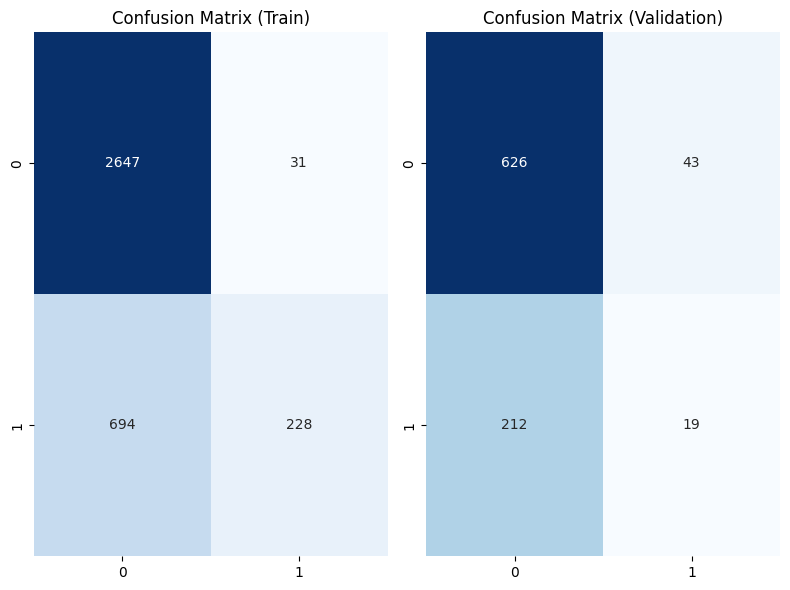

In [ ]:
eval_cm(final_clf_dt,X_train,y_train,X_val,y_val,drop_id_col_list)

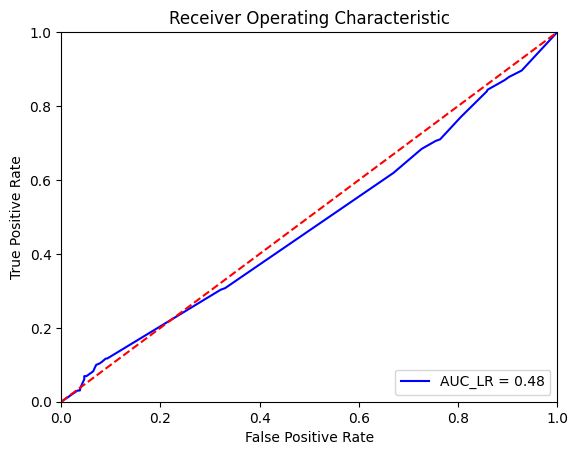

In [ ]:
# Compute ROC curve and ROC area
probs = final_clf_dt.predict_proba(X_val.drop(drop_id_col_list, axis=1, errors='ignore'))
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_val, preds)
roc_auc = auc(fpr, tpr)


# Creating the ROC curve plot
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC_LR = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


### Classifier 2 - XGB Classifier


In [ ]:
# Define the hyperparameter search space
space = {
    #"n_estimators": hp.choice("n_estimators", [100, 200, 300, 500, 1000]),
    "max_depth": hp.choice("max_depth", [3, 4, 5, 6, 7, 8, 10, 11, 12, 15, 20]),
 #   "min_child_weight": hp.choice("min_child_weight", [2, 3]),
    "gamma": hp.uniform("gamma", 0, 0.0005),
    "subsample": hp.uniform("subsample", 0.1, 1),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.5, 1),
    "reg_alpha": hp.loguniform("reg_alpha", np.log(0.01), np.log(1)),
    #"reg_lambda": hp.loguniform("reg_lambda", np.log(0.0001), np.log(1))
}

#defining the objective function
def objective(params):
    model = xgb.XGBClassifier(**params, random_state=321)
    model.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)
    score = f1_score(y_val, model.predict(X_val.drop(drop_id_col_list, axis=1, errors='ignore')))
    return -score  # Minimize the negative of F1-score

trials = Trials()
best_xgb_param = fmin(fn=objective,
           space=space,
           algo=tpe.suggest,
           max_evals=30)

  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 30/30 [00:20<00:00,  1.48trial/s, best loss: -0.2755344418052256]


In [ ]:
# Print the best hyperparameters
print("Best hyperparameters:", best_xgb_param)

Best hyperparameters: {'colsample_bytree': 0.6628291397939796, 'gamma': 5.7816129802119353e-05, 'max_depth': 9, 'reg_alpha': 0.08892947277619177, 'subsample': 0.1391524483475447}


In [ ]:
# NOTE: The best hyperparameters may not be the same as the ones used in the final model
best_param = {'colsample_bytree': 0.8011137517906433, 'gamma': 0.0003315092691686855,
 'max_depth': 7, 'reg_alpha': 0.20064996416845873, 'subsample': 0.19265865309365698}

In [ ]:
# Train the final model with the best hyperparameters
model_xgb = xgb.XGBClassifier(**best_param)
model_xgb.fit(X_train.drop(drop_id_col_list, axis=1, errors='ignore'), y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8011137517906433, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.0003315092691686855, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=None, ...)

In [ ]:
evaluate_model(model_xgb,X_train,y_train,X_val,y_val,drop_id_col_list)

Training Set:
F1-score: 0.8440046565774156
Accuracy: 0.9255555555555556

Validation Set:
F1-score: 0.24578313253012052
Accuracy: 0.6522222222222223


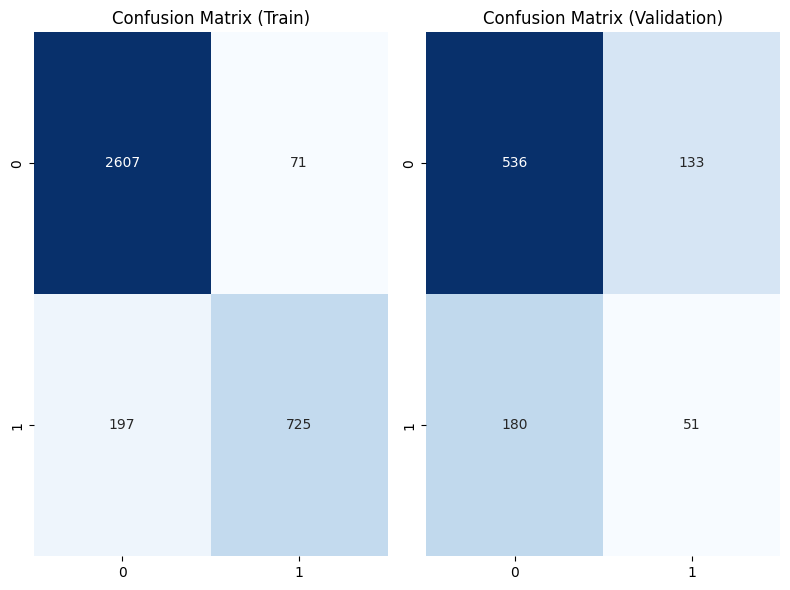

In [ ]:
# Evaluate the final XGBoost model
eval_cm(model_xgb,X_train,y_train,X_val,y_val,drop_id_col_list)

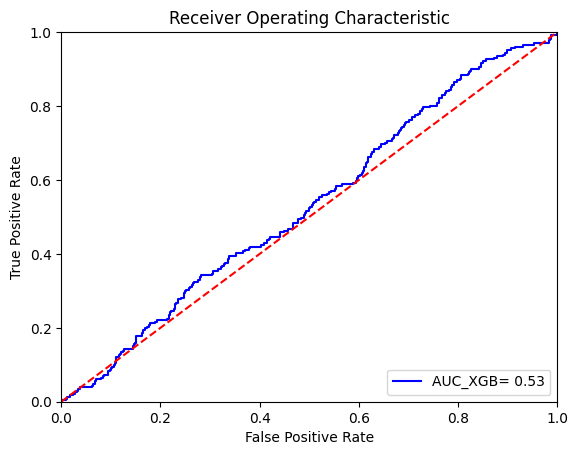

In [ ]:
# Compute ROC curve and ROC area
probs = model_xgb.predict_proba(X_val.drop(drop_id_col_list, axis=1, errors='ignore'))
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_val, preds)
roc_auc = auc(fpr, tpr)


# Creating the ROC curve plot
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC_XGB= %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


#### Save the trained model

We use pickle to save the trained model for future inference.

In [ ]:
# Save the model using pickle
import pickle
# Pickle the model
file_path = os.path.join(current_dir, "..", "model","physician_conversion.pkl")
file_path = os.path.abspath(file_path)
with open(file_path, "wb") as f:
    pickle.dump(model_xgb, f)


### Inference Data
- Saving Test Data as Inference set
- Training data for Model Monitoring

In [ ]:
inference_df = X_test.copy()
# inference_df['TARGET'] = y_test
inference_df.head()

,NPI_ID,HCP_ID,Age,Number_of_Rx,Rx_last_1_Month,Rx_last_3_Month,Rx_last_6_Month,Rx_last_12_Month,Claims_last_1_Month,Claims_last_3_Month,...,Promotional_medscape_last_3_month,Promotional_medscape_last_6_month,F2F_visit,F2F_visit_last_1_month,F2F_visit_last_3_month,VRC_visit_last_3_month,VRC_visit_last_6_month,VRC_visit_last_12_month,HCO_Affiliation_Type_Contract,HCO_Affiliation_Type_Referral
4637,4982891,HCP_4638,82,133,184,302,330,378,264,444,...,23,46,2,3,5,5,9,10,0,1
3387,2838371,HCP_3388,28,338,425,773,1544,2153,204,328,...,14,17,1,2,3,4,6,11,1,0
2730,4488773,HCP_2731,38,1100,1202,2180,3876,4878,264,486,...,20,23,2,3,4,5,7,8,0,0
593,8623941,HCP_594,84,866,1005,1280,1989,3550,56,102,...,17,33,2,4,5,4,6,9,1,0
2916,8596687,HCP_2917,62,908,1576,2036,2167,4210,103,179,...,26,46,2,4,7,4,8,10,0,1


#### SAVE INFERENCE DATA
> IN REAL WORLD SCENARIO, THIS DATA WILL BE USED FOR PREDICTION AND WILL BE FETCHED AT BATCH LEVEL FROM DATABASE OR FILE SYSTEM

In [ ]:

# Save the inference data
file_path = os.path.join(current_dir, "..", "data", "Inference_data", "Inference_data.csv")
file_path = os.path.abspath(file_path)

inference_df.to_csv(file_path)

In [ ]:
##Save Validation Data for Shap
df_validation = X_val.copy()
df_validation['TARGET'] = y_val

file_path = os.path.join(current_dir, "..", "data", "shap_data", "Validation_data.csv")
file_path = os.path.abspath(file_path)
df_validation.to_csv(file_path)

In [ ]:
##Save Train Data for Shap
df_train = X_train.copy()
df_train['TARGET'] = y_train

file_path = os.path.join(current_dir, "..", "data", "shap_data", "train_data.csv")
file_path = os.path.abspath(file_path)
df_train.to_csv(file_path)